# 02 — Train HCCS Scorer

Trains the Hallucination Context Contrast Scorer (HCCS) using the contrastive
triplets and pre-computed embeddings from notebook 01.

**What it produces:** `checkpoints/hccs_best.pt` — trained MLP scorer weights.

**Pipeline:**
1. Load pre-computed embeddings (query, chunk, gold_indices)
2. Build training tensors from triplets
3. Train MLP with InfoNCE loss (batch_size=256, 10 epochs)
4. Validate: scorer should rank gold > non-gold >85% of the time
5. Save best checkpoint to Drive

**Runtime:** ~5 minutes on T4 GPU

---
Run `01_data_pipeline.ipynb` first to generate embeddings and triplets.

## Setup

In [27]:
!pip install torch transformers numpy tqdm --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [28]:
import sys, os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_DIR = '/content/drive/MyDrive/HaluGuard'
except ImportError:
    REPO_DIR = os.path.abspath('..')

sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)
!pip install -e '.[dev]' -q

from notebooks.utils import check_gpu, save_checkpoint, get_drive_path
DEVICE = check_gpu()


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: file:///home does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
GPU found: NVIDIA GeForce RTX 3050 Laptop GPU (4.0 GB VRAM)


In [29]:
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from haluguard.hccs import HCCSScorer, infonce_loss

DRIVE_DIR = get_drive_path('HaluGuard')
EMB_DIR   = DRIVE_DIR / 'data' / 'embeddings'
CKPT_DIR  = DRIVE_DIR / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Embeddings dir: {EMB_DIR}')
print(f'Checkpoints dir: {CKPT_DIR}')

Embeddings dir: /home/daniel/HaluGuard_drive_sim/HaluGuard/data/embeddings
Checkpoints dir: /home/daniel/HaluGuard_drive_sim/HaluGuard/checkpoints


## 1. Load Pre-computed Embeddings

In [30]:
query_embs  = torch.load(EMB_DIR / 'query_embeddings.pt')   # [8033, 768]
chunk_embs  = torch.load(EMB_DIR / 'chunk_embeddings.pt')   # list of [n_chunks_i, 768]
gold_indices = torch.load(EMB_DIR / 'gold_indices.pt')       # list of ints

print(f'Query embeddings: {query_embs.shape}')
print(f'Examples with chunks: {len(chunk_embs)}')
print(f'Gold indices: {len(gold_indices)}')

Query embeddings: torch.Size([8033, 768])
Examples with chunks: 8033
Gold indices: 8033


## 2. Build Training Tensors from Triplets

For each example: positive = chunk_embs[gold_idx], negatives = all other chunks.
We build (query, positive, negative) embedding triplets directly.

In [31]:
queries_t   = []
positives_t = []
negatives_t = []

for i in range(len(query_embs)):
    gold_idx = gold_indices[i]
    n_chunks = chunk_embs[i].shape[0]

    if gold_idx < 0 or gold_idx >= n_chunks or n_chunks < 2:
        continue

    q_emb = query_embs[i]         # [768]
    pos_emb = chunk_embs[i][gold_idx]  # [768]

    for j in range(n_chunks):
        if j != gold_idx:
            queries_t.append(q_emb)
            positives_t.append(pos_emb)
            negatives_t.append(chunk_embs[i][j])

queries_t   = torch.stack(queries_t)
positives_t = torch.stack(positives_t)
negatives_t = torch.stack(negatives_t)

print(f'Total triplets: {len(queries_t)}')

num_examples = len(query_embs)
valid_indices = []
for i in range(num_examples):
    gold_idx = gold_indices[i]
    n_chunks = chunk_embs[i].shape[0]
    # Ensure gold index is within bounds and we have at least one negative distractor
    if 0 <= gold_idx < n_chunks and n_chunks >= 2:
        valid_indices.append(i)

print(f"Total valid tasks: {len(valid_indices)} (out of {num_examples})")

# Shuffle
# perm = torch.randperm(len(queries_t))
# queries_t   = queries_t[perm]
# positives_t = positives_t[perm]
# negatives_t = negatives_t[perm]
random.shuffle(valid_indices)


# 90/10 train/val split
split = int(0.9 * num_examples)
train_indices = set(valid_indices[:split])
val_indices = set(valid_indices[split:])

print(f"split index: {split}")
print(f"Unique tasks for training: {len(train_indices)}")
print(f"Unique tasks for validation: {len(val_indices)}")

Total triplets: 80203
Total valid tasks: 8026 (out of 8033)
split index: 7229
Unique tasks for training: 7229
Unique tasks for validation: 797


In [32]:
# 90/10 train/val split
# split = int(0.9 * len(queries_t))
def expand_triplets(target_indices):
    q_list, p_list, n_list = [], [], []
    for i in target_indices:
        gold_idx = gold_indices[i]
        chunks = chunk_embs[i]
        n_chunks = chunks.shape[0]

        if gold_idx < 0 or gold_idx >= n_chunks or n_chunks < 2:
            continue

        q_emb = query_embs[i]
        pos_emb = chunks[gold_idx]

        for j in range(n_chunks):
            if j != gold_idx:
                q_list.append(q_emb)
                p_list.append(pos_emb)
                n_list.append(chunks[j])
    
    return torch.stack(q_list), torch.stack(p_list), torch.stack(n_list)

# Generate the isolated sets
train_q, train_p, train_n = expand_triplets(train_indices)
val_q, val_p, val_n = expand_triplets(val_indices)

BATCH_SIZE = 256

train_loader = DataLoader(
    TensorDataset(train_q, train_p, train_n),
    batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(val_q, val_p, val_n),
    batch_size=BATCH_SIZE,
)
print(f'Train: {train_q.shape[0]} triplets ({len(train_loader)} batches)')
print(f'Val:   {val_q.shape[0]} triplets ({len(val_loader)} batches)')

Train: 72058 triplets (282 batches)
Val:   8145 triplets (32 batches)


In [ ]:
try:
    from sklearn.metrics import roc_auc_score
    from sklearn.linear_model import LogisticRegression
    import torch.nn.functional as F

    # Build a flat dataset of [query||chunk] embeddings with binary labels
    X, y = [], []
    for i in val_indices:
        gold_idx = gold_indices[i]
        chunks = chunk_embs[i]
        for j in range(chunks.shape[0]):
            X.append(torch.cat([query_embs[i], chunks[j]]).numpy())
            y.append(1 if j == gold_idx else 0)

    X, y = np.array(X), np.array(y)
    lr = LogisticRegression(max_iter=1000).fit(X, y)
    print(f"Logistic regression AUC: {roc_auc_score(y, lr.predict_proba(X)[:,1]):.3f}")
except ImportError:
    print("run pip install scikit-learn to run Logistic Regression AUC")

Logistic regression AUC: 0.863


## 3. Train the MLP Scorer

In [34]:
EPOCHS = 80
LR     = 3e-4
TAU    = 0.05
MINE_EVERY_N_EPOCHS = 3

scorer = HCCSScorer(input_dim=3072, hidden_dim=256, dropout=0.3).to(DEVICE)
optimizer = torch.optim.AdamW(scorer.parameters(), lr=LR, weight_decay=1e-1)
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=5
)
plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.3, patience=10, min_lr=1e-5
)

best_val_acc = 0.0
train_losses = []

def make_input(q, c):

    q_norm = F.normalize(q, p=2, dim=1)
    c_norm = F.normalize(c, p=2, dim=1)
    diff = q_norm - c_norm
    prod = q_norm * c_norm
    return torch.cat([q_norm, c_norm, diff, prod], dim=1) # now 1536*2 = 3072 dim

for epoch in range(1, EPOCHS + 1):

    # --- Training ---
    scorer.train()
    epoch_loss = 0.0
    for q, p, n in train_loader:
        q, p, n = q.to(DEVICE), p.to(DEVICE), n.to(DEVICE)

        pos_score = scorer(make_input(q, p))  # (B, 1)
        neg_score = scorer(make_input(q, n))

        loss = infonce_loss(pos_score, neg_score, tau=TAU)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    mean_loss = epoch_loss / len(train_loader)
    train_losses.append(mean_loss)

    scorer.eval()
    all_pos_scores, all_neg_scores = [], []
    with torch.no_grad():
        for q, p, n in val_loader:
            q, p, n = q.to(DEVICE), p.to(DEVICE), n.to(DEVICE)
            all_pos_scores.extend(scorer(make_input(q, p)).squeeze(1).tolist())
            all_neg_scores.extend(scorer(make_input(q, n)).squeeze(1).tolist())

    print(f"Pos scores — mean: {np.mean(all_pos_scores):.3f}, std: {np.std(all_pos_scores):.3f}")
    print(f"Neg scores — mean: {np.mean(all_neg_scores):.3f}, std: {np.std(all_neg_scores):.3f}")

    # --- Validation ---
    scorer.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for q, p, n in val_loader:
            q, p, n = q.to(DEVICE), p.to(DEVICE), n.to(DEVICE)
            pos_s = scorer(make_input(q, p))
            neg_s = scorer(make_input(q, n))
            correct += (pos_s > neg_s).sum().item()
            total += q.size(0)

    val_acc = correct / max(total, 1)

    if epoch <= 7:
        warmup_scheduler.step()
    else:
        plateau_scheduler.step(val_acc)

    print(f"Current LR: {optimizer.param_groups[0]['lr']}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint(scorer, 'hccs_best.pt', drive_subdir='HaluGuard/checkpoints')
        print(f'  -> New best ({val_acc:.1%}) saved')

    # --- Rank-1 Accuracy ---
    scorer.eval()
    rank1_correct, rank1_total = 0, 0
    with torch.no_grad():
        for i in val_indices:
            gold_idx = gold_indices[i]
            chunks = chunk_embs[i]
            n_chunks = chunks.shape[0]
            
            if gold_idx < 0 or gold_idx >= n_chunks:
                continue
            
            # Score every chunk against the query
            q = query_embs[i].unsqueeze(0).expand(n_chunks, -1).to(DEVICE)
            c = chunks.to(DEVICE)
            scores = scorer(make_input(q, c)).squeeze(1)
            
            predicted_best = scores.argmax().item()
            if predicted_best == gold_idx:
                rank1_correct += 1
            rank1_total += 1

    rank1_acc = rank1_correct / max(rank1_total, 1)
    print(f'Epoch {epoch:2d}/{EPOCHS} | loss: {mean_loss:.4f} | val_acc: {val_acc:.1%} | rank1: {rank1_acc:.1%}')

print(f'\nTraining complete. Best val accuracy: {best_val_acc:.1%}')
print('>85% = working. ~50% = random, use fallback.')

Pos scores — mean: 0.994, std: 0.001
Neg scores — mean: 0.994, std: 0.001
Current LR: 8.399999999999998e-05
Saved checkpoint: /home/daniel/HaluGuard_drive_sim/HaluGuard/checkpoints/hccs_best.pt
  -> New best (53.8%) saved
Epoch  1/80 | loss: 0.9115 | val_acc: 53.8% | rank1: 18.9%
Pos scores — mean: 0.998, std: 0.000
Neg scores — mean: 0.998, std: 0.000
Current LR: 0.00013799999999999997
Epoch  2/80 | loss: 0.6972 | val_acc: 53.7% | rank1: 18.3%
Pos scores — mean: 0.997, std: 0.009
Neg scores — mean: 0.995, std: 0.032
Current LR: 0.00019199999999999995
Saved checkpoint: /home/daniel/HaluGuard_drive_sim/HaluGuard/checkpoints/hccs_best.pt
  -> New best (54.3%) saved
Epoch  3/80 | loss: 0.6908 | val_acc: 54.3% | rank1: 19.8%
Pos scores — mean: 0.994, std: 0.010
Neg scores — mean: 0.977, std: 0.134
Current LR: 0.00024599999999999996
Epoch  4/80 | loss: 0.6698 | val_acc: 53.8% | rank1: 22.1%
Pos scores — mean: 0.974, std: 0.059
Neg scores — mean: 0.942, std: 0.186
Current LR: 0.0003
Saved ch

In [35]:
# Check average chunks per query
chunk_counts = [chunk_embs[i].shape[0] for i in valid_indices]
print(f"Chunks per query — mean: {np.mean(chunk_counts):.1f}, min: {min(chunk_counts)}, max: {max(chunk_counts)}")

Chunks per query — mean: 11.0, min: 2, max: 75


In [36]:
# Score a few raw embedding pairs without the MLP — just cosine similarity
from torch.nn.functional import cosine_similarity

sample_indices = list(val_indices)[:200]
cos_correct = 0
for i in sample_indices:
    gold_idx = gold_indices[i]
    chunks = chunk_embs[i]
    q = query_embs[i].unsqueeze(0).expand(chunks.shape[0], -1)
    sims = cosine_similarity(q, chunks)
    cos_correct += (sims.argmax().item() == gold_idx)
print(f"Cosine similarity rank-1 accuracy: {cos_correct/len(sample_indices):.1%}")

Cosine similarity rank-1 accuracy: 19.5%


In [37]:
# Quick check — how many unique queries are in training?
print(f"Unique train queries: {len(train_indices)}")
print(f"Train triplets: {train_q.shape[0]}")
print(f"Avg triplets per query: {train_q.shape[0] / len(train_indices):.1f}")

Unique train queries: 7229
Train triplets: 72058
Avg triplets per query: 10.0


## 4. Validate

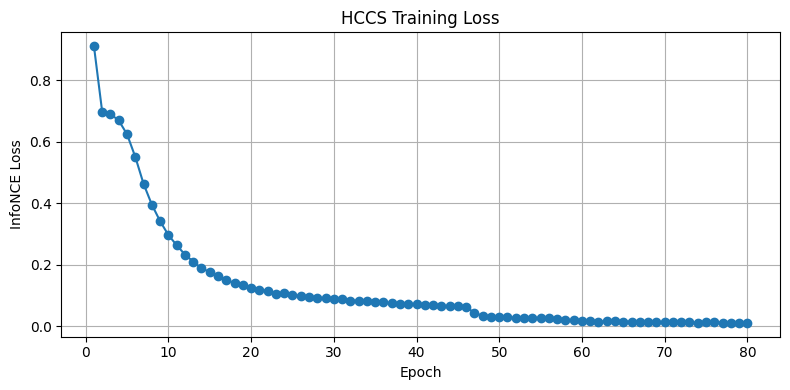

In [38]:
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('InfoNCE Loss')
    plt.title('HCCS Training Loss')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(CKPT_DIR / 'training_loss.png', dpi=150)
    plt.show()
except ImportError:
    print('matplotlib not installed - skipping plot')

In [39]:
# Qualitative check: score some positive vs negative chunks
scorer.eval()

print('Sample scores (positive should be > negative):\n')
for i in range(min(5, len(queries_t) - split)):
    idx = split + i
    q = queries_t[idx].unsqueeze(0).to(DEVICE)
    p = positives_t[idx].unsqueeze(0).to(DEVICE)
    n = negatives_t[idx].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pos_s = scorer(make_input(q, p)).item()
        neg_s = scorer(make_input(q, n)).item()

    status = 'OK' if pos_s > neg_s else 'WRONG'
    print(f'  [{status}] pos={pos_s:.3f}  neg={neg_s:.3f}')

Sample scores (positive should be > negative):

  [OK] pos=0.773  neg=0.077
  [OK] pos=0.773  neg=0.195
  [OK] pos=0.773  neg=-0.049
  [OK] pos=0.773  neg=0.142
  [OK] pos=0.690  neg=0.093
